In [50]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from skimage.feature import hog
from skimage.feature import local_binary_pattern
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [51]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [52]:
DATASET_PATH = "./chest_xray"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

CLASSES = ["NORMAL", "PNEUMONIA"]

print("Dataset path:", DATASET_PATH)
print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

Dataset path: ./chest_xray
Train path: ./chest_xray/train
Validation path: ./chest_xray/val
Test path: ./chest_xray/test


In [53]:
print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Train folder exists:", os.path.exists(TRAIN_PATH))
print("Validation folder exists:", os.path.exists(VAL_PATH))
print("Test folder exists:", os.path.exists(TEST_PATH))

if os.path.exists(DATASET_PATH):
    print("\nDataset contents:")
    print(os.listdir(DATASET_PATH))

Dataset exists: True
Train folder exists: True
Validation folder exists: True
Test folder exists: True

Dataset contents:
['test', 'chest_xray', '__MACOSX', 'train', 'val']


In [54]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

def count_images(folder):
    counts = {}

    for class_name in CLASSES:
        class_path = os.path.join(folder, class_name)

        if os.path.exists(class_path):
            count = sum(
                1 for file in os.listdir(class_path)
                if file.lower().endswith(IMAGE_EXTENSIONS)
            )
        else:
            count = 0

        counts[class_name] = count

    return counts


for split_name, split_path in [
    ("Train", TRAIN_PATH),
    ("Validation", VAL_PATH),
    ("Test", TEST_PATH)
]:
    
    print(f"\n{split_name}")
    print("-" * 30)
    
    counts = count_images(split_path)
    
    for class_name, count in counts.items():
        print(f"{class_name}: {count}")


Train
------------------------------
NORMAL: 1341
PNEUMONIA: 3875

Validation
------------------------------
NORMAL: 8
PNEUMONIA: 8

Test
------------------------------
NORMAL: 234
PNEUMONIA: 390


In [55]:
data = []

for split_name, split_path in [
    ("Train", TRAIN_PATH),
    ("Validation", VAL_PATH),
    ("Test", TEST_PATH)
]:
    
    counts = count_images(split_path)

    for class_name, count in counts.items():
        data.append({
            "Dataset": split_name,
            "Class": class_name,
            "Number of Images": count
        })

class_balance = pd.DataFrame(data)

display(class_balance)

,Dataset,Class,Number of Images
0,Train,NORMAL,1341
1,Train,PNEUMONIA,3875
2,Validation,NORMAL,8
3,Validation,PNEUMONIA,8
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


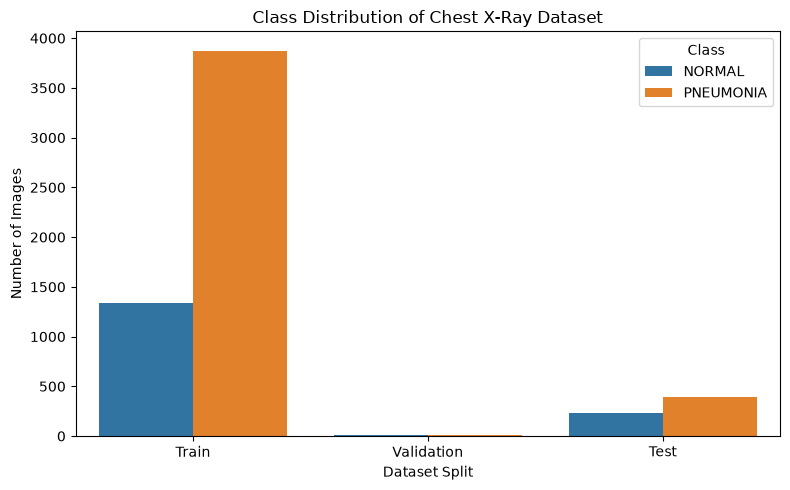

In [56]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=class_balance,
    x="Dataset",
    y="Number of Images",
    hue="Class"
)

plt.title("Class Distribution of Chest X-Ray Dataset")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [57]:
def get_image_paths(folder, class_name):
    
    class_path = os.path.join(folder, class_name)
    
    image_paths = [
        os.path.join(class_path, file)
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]
    
    return image_paths


normal_images = get_image_paths(TRAIN_PATH, "NORMAL")
pneumonia_images = get_image_paths(TRAIN_PATH, "PNEUMONIA")

print("Normal images:", len(normal_images))
print("Pneumonia images:", len(pneumonia_images))

Normal images: 1341
Pneumonia images: 3875


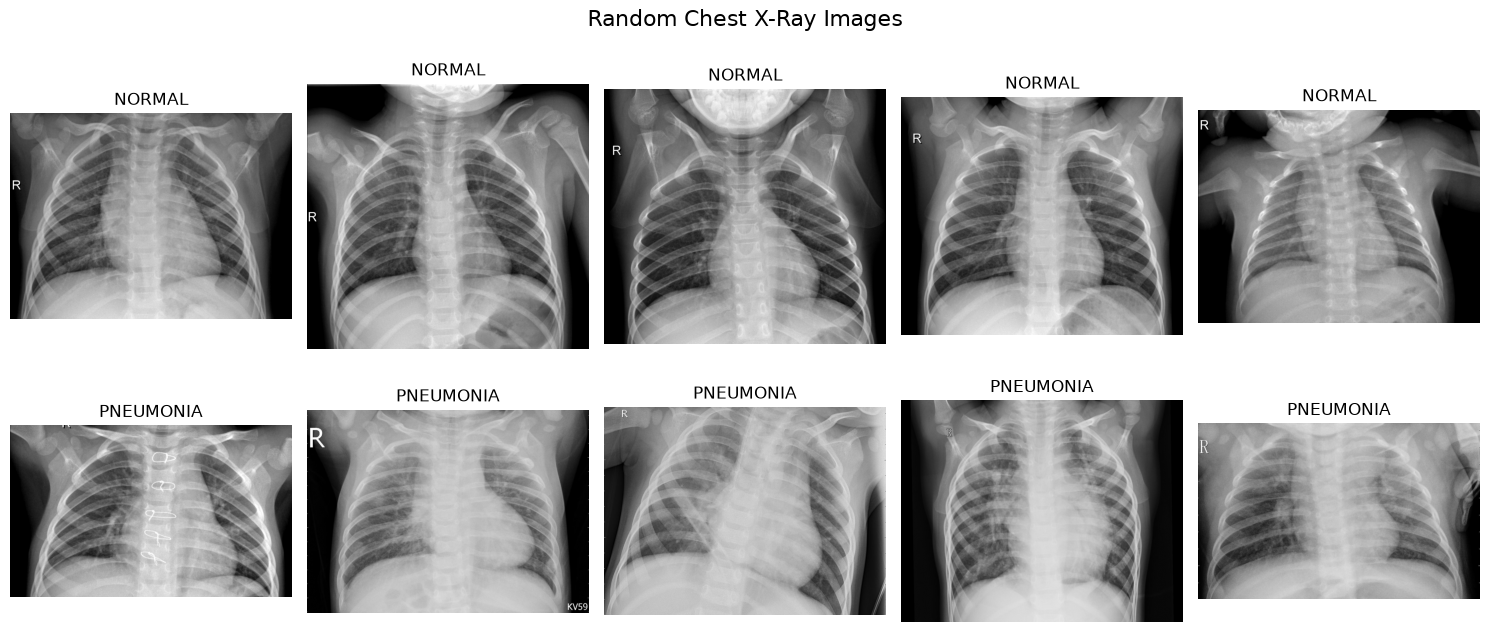

In [58]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for row, class_name in enumerate(CLASSES):
    
    image_paths = get_image_paths(TRAIN_PATH, class_name)
    
    selected_paths = random.sample(
        image_paths,
        min(5, len(image_paths))
    )
    
    for col, image_path in enumerate(selected_paths):
        
        image = Image.open(image_path)
        
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle("Random Chest X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()

In [59]:
IMG_SIZE = (128, 128)

print("Target image size:", IMG_SIZE)

Target image size: (128, 128)


In [60]:
def load_image(image_path):
    
    image = Image.open(image_path).convert("L")
    
    image = image.resize(IMG_SIZE)
    
    image = np.array(image, dtype=np.float32)
    
    image = image / 255.0
    
    return image


sample_image = load_image(normal_images[0])

print("Image shape:", sample_image.shape)
print("Minimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())

Image shape: (128, 128)
Minimum pixel value: 0.0
Maximum pixel value: 0.92156863


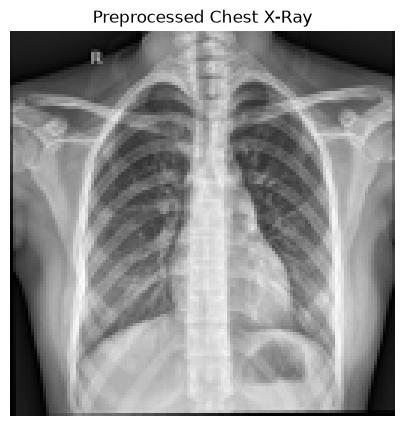

In [61]:
plt.figure(figsize=(5, 5))

plt.imshow(sample_image, cmap="gray")

plt.title("Preprocessed Chest X-Ray")
plt.axis("off")

plt.show()

In [62]:
def extract_hog(image):
    
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    
    return features


hog_features = extract_hog(sample_image)

print("HOG feature vector shape:", hog_features.shape)

HOG feature vector shape: (8100,)


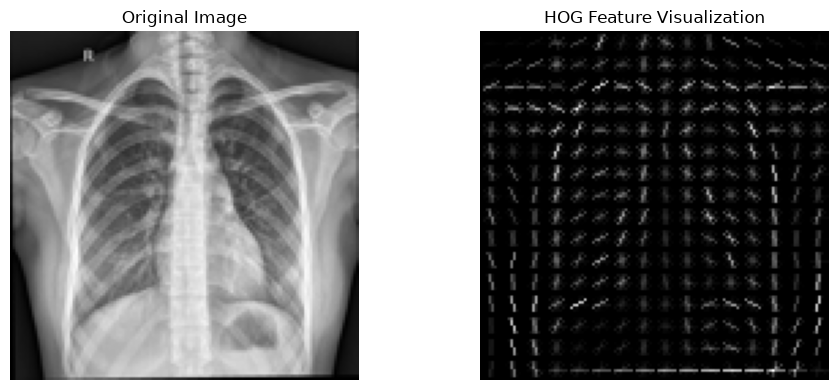

In [63]:
hog_features, hog_image = hog(
    sample_image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Feature Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
def extract_lbp(image):
    
    radius = 1
    points = 8
    
    lbp = local_binary_pattern(
        image,
        points,
        radius,
        method="uniform"
    )
    
    n_bins = points + 2
    
    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_bins + 1),
        range=(0, n_bins),
        density=True
    )
    
    return histogram


lbp_features = extract_lbp(sample_image)

print("LBP feature vector shape:", lbp_features.shape)

LBP feature vector shape: (10,)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


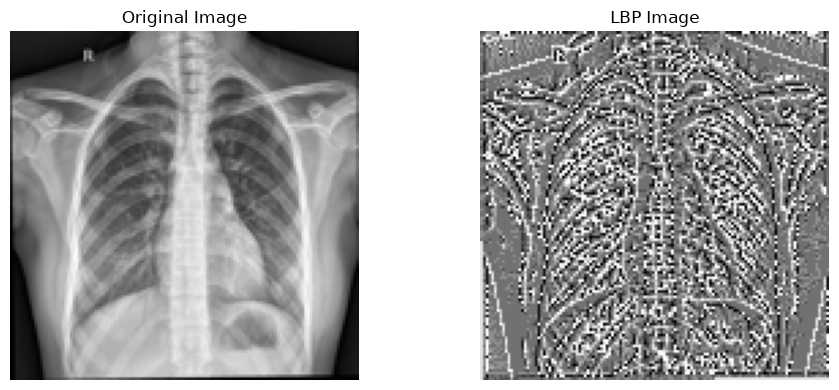

In [65]:
lbp_image = local_binary_pattern(
    sample_image,
    P=8,
    R=1,
    method="uniform"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lbp_image, cmap="gray")
plt.title("LBP Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [66]:
def extract_glcm(image):
    
    # Convert normalized image back to 8-bit
    image_uint8 = (image * 255).astype(np.uint8)
    
    # Quantize to 8 gray levels
    image_quantized = image_uint8 // 32
    
    glcm = graycomatrix(
        image_quantized,
        distances=[1],
        angles=[
            0,
            np.pi / 4,
            np.pi / 2,
            3 * np.pi / 4
        ],
        levels=8,
        symmetric=True,
        normed=True
    )
    
    properties = [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "energy",
        "correlation",
        "ASM"
    ]
    
    features = []
    
    for property_name in properties:
        
        values = graycoprops(
            glcm,
            property_name
        )
        
        features.extend(values.flatten())
    
    return np.array(features)


glcm_features = extract_glcm(sample_image)

print("GLCM feature vector shape:", glcm_features.shape)
print(glcm_features)

GLCM feature vector shape: (24,)
[0.32554134 0.500961   0.31520669 0.49054498 0.28690945 0.37820076
 0.24483268 0.37100874 0.8603911  0.82242748 0.88393552 0.82578127
 0.30938778 0.29016235 0.32540743 0.29193715 0.94575683 0.91539021
 0.94752911 0.91714942 0.0957208  0.08419419 0.10588999 0.0852273 ]


In [67]:
def extract_all_features(image):
    
    hog_features = extract_hog(image)
    lbp_features = extract_lbp(image)
    glcm_features = extract_glcm(image)
    
    combined_features = np.concatenate([
        hog_features,
        lbp_features,
        glcm_features
    ])
    
    return combined_features


combined_features = extract_all_features(sample_image)

print("Combined feature vector shape:")
print(combined_features.shape)

Combined feature vector shape:
(8134,)


In [68]:
def extract_features_from_folder(folder):
    
    X = []
    y = []
    
    for label, class_name in enumerate(CLASSES):
        
        image_paths = get_image_paths(
            folder,
            class_name
        )
        
        print(
            f"Processing {class_name}: "
            f"{len(image_paths)} images"
        )
        
        for image_path in image_paths:
            
            try:
                image = load_image(image_path)
                
                features = extract_all_features(image)
                
                X.append(features)
                y.append(label)
                
            except Exception as error:
                print(
                    "Error processing:",
                    image_path,
                    error
                )
    
    return np.array(X), np.array(y)

In [69]:
X_features, y_features = extract_features_from_folder(
    TRAIN_PATH
)

print("\nFeature matrix shape:", X_features.shape)
print("Label array shape:", y_features.shape)

Processing NORMAL: 1341 images
Processing PNEUMONIA: 3875 images

Feature matrix shape: (5216, 8134)
Label array shape: (5216,)


In [70]:
# First split:
# 70% training
# 30% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X_features,
    y_features,
    test_size=0.30,
    random_state=SEED,
    stratify=y_features
)

# Second split:
# 15% validation
# 15% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (3651, 8134)
Validation set: (782, 8134)
Testing set: (783, 8134)


In [71]:
print("Training classes:")
print(np.bincount(y_train))

print("\nValidation classes:")
print(np.bincount(y_val))

print("\nTesting classes:")
print(np.bincount(y_test))

Training classes:
[ 939 2712]

Validation classes:
[201 581]

Testing classes:
[201 582]


In [72]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [73]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

print("Class indices:")
print(train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Class indices:
{'NORMAL': 0, 'PNEUMONIA': 1}


In [74]:
val_generator = validation_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Validation images: 16
Test images: 624


In [75]:
def create_cnn(
    filters1=32,
    filters2=64,
    dense_units=128,
    learning_rate=0.001
):
    
    model = models.Sequential([
        
        layers.Input(
            shape=(128, 128, 1)
        ),
        
        layers.Conv2D(
            filters1,
            (3, 3),
            activation="relu"
        ),
        
        layers.MaxPooling2D(
            (2, 2)
        ),
        
        layers.Conv2D(
            filters2,
            (3, 3),
            activation="relu"
        ),
        
        layers.MaxPooling2D(
            (2, 2)
        ),
        
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),
        
        layers.MaxPooling2D(
            (2, 2)
        ),
        
        layers.Flatten(),
        
        layers.Dense(
            dense_units,
            activation="relu"
        ),
        
        layers.Dropout(0.5),
        
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [76]:
cnn_model = create_cnn()

cnn_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [78]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.8359 - loss: 0.3711 - val_accuracy: 0.8125 - val_loss: 0.4525
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.8993 - loss: 0.2557 - val_accuracy: 0.6875 - val_loss: 0.6432
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.9248 - loss: 0.1960 - val_accuracy: 0.8125 - val_loss: 0.3273
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.9340 - loss: 0.1764 - val_accuracy: 0.7500 - val_loss: 0.7406
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.9406 - loss: 0.1597 - val_accuracy: 0.7500 - val_loss: 0.5816
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.9521 - loss: 0.1319 - val_accuracy: 0.6250 - val_loss: 0.6801


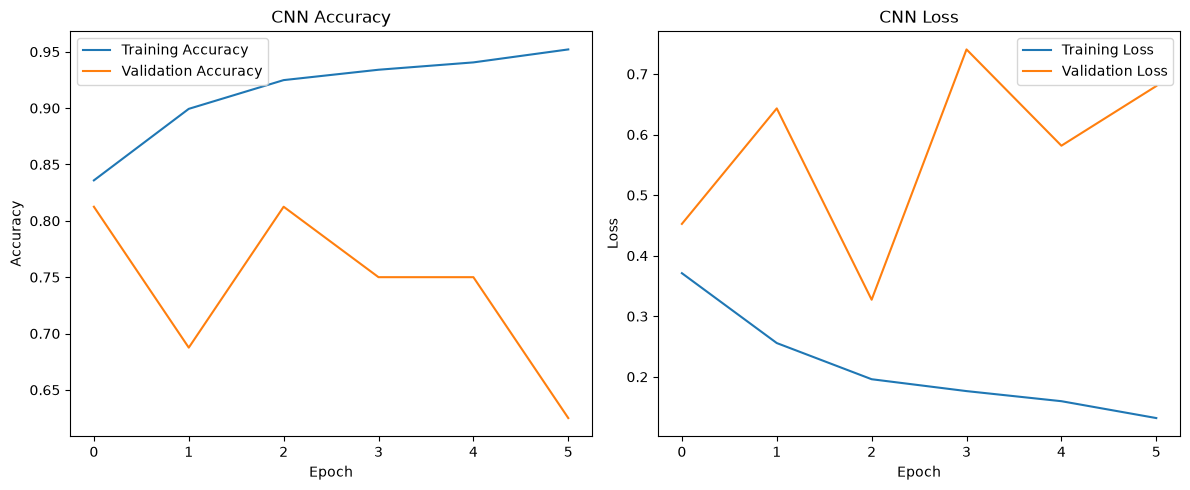

In [79]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [80]:
hyperparameters = [
    {
        "filters1": 32,
        "filters2": 64,
        "dense_units": 128,
        "learning_rate": 0.001
    },
    
    {
        "filters1": 32,
        "filters2": 64,
        "dense_units": 256,
        "learning_rate": 0.001
    },
    
    {
        "filters1": 64,
        "filters2": 128,
        "dense_units": 128,
        "learning_rate": 0.001
    },
    
    {
        "filters1": 32,
        "filters2": 64,
        "dense_units": 128,
        "learning_rate": 0.0001
    }
]

for i, parameters in enumerate(hyperparameters):
    print(f"Configuration {i + 1}:")
    print(parameters)
    print()

Configuration 1:
{'filters1': 32, 'filters2': 64, 'dense_units': 128, 'learning_rate': 0.001}

Configuration 2:
{'filters1': 32, 'filters2': 64, 'dense_units': 256, 'learning_rate': 0.001}

Configuration 3:
{'filters1': 64, 'filters2': 128, 'dense_units': 128, 'learning_rate': 0.001}

Configuration 4:
{'filters1': 32, 'filters2': 64, 'dense_units': 128, 'learning_rate': 0.0001}



In [81]:
# CNN cross-validation can take a long time on the complete dataset.
# A subset is therefore used for hyperparameter comparison.

CV_SAMPLE_SIZE = 1500

all_paths = []
all_labels = []

for label, class_name in enumerate(CLASSES):
    
    image_paths = get_image_paths(
        TRAIN_PATH,
        class_name
    )
    
    for image_path in image_paths:
        all_paths.append(image_path)
        all_labels.append(label)


all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

if len(all_paths) > CV_SAMPLE_SIZE:
    
    selected_indices, _ = train_test_split(
        np.arange(len(all_paths)),
        train_size=CV_SAMPLE_SIZE,
        random_state=SEED,
        stratify=all_labels
    )
    
    cv_paths = all_paths[selected_indices]
    cv_labels = all_labels[selected_indices]

else:
    
    cv_paths = all_paths
    cv_labels = all_labels


print("Images used for cross-validation:", len(cv_paths))

Images used for cross-validation: 1500


In [82]:
def load_image_for_tf(path, label):
    
    image = tf.io.read_file(path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=1
    )
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0
    
    return image, tf.cast(
        label,
        tf.float32
    )


def create_tf_dataset(
    paths,
    labels,
    batch_size=32,
    shuffle=True
):
    
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )
    
    dataset = dataset.map(
        load_image_for_tf,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=SEED
        )
    
    dataset = dataset.batch(batch_size)
    
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )
    
    return dataset

In [83]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

cv_results = []

for config_number, parameters in enumerate(
    hyperparameters,
    start=1
):
    
    print("=" * 60)
    print("Configuration:", config_number)
    print(parameters)
    print("=" * 60)
    
    fold_scores = []
    
    for fold, (train_indices, val_indices) in enumerate(
        skf.split(cv_paths, cv_labels),
        start=1
    ):
        
        print(f"Fold {fold}")
        
        train_ds = create_tf_dataset(
            cv_paths[train_indices],
            cv_labels[train_indices]
        )
        
        val_ds = create_tf_dataset(
            cv_paths[val_indices],
            cv_labels[val_indices],
            shuffle=False
        )
        
        model = create_cnn(
            **parameters
        )
        
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=3,
            verbose=0
        )
        
        probabilities = model.predict(
            val_ds,
            verbose=0
        ).ravel()
        
        predictions = (
            probabilities >= 0.5
        ).astype(int)
        
        accuracy = accuracy_score(
            cv_labels[val_indices],
            predictions
        )
        
        fold_scores.append(accuracy)
        
        print(
            f"Fold Accuracy: {accuracy:.4f}"
        )
    
    mean_accuracy = np.mean(
        fold_scores
    )
    
    cv_results.append({
        "Configuration": config_number,
        "Parameters": parameters,
        "Mean CV Accuracy": mean_accuracy
    })
    
    print(
        f"Mean CV Accuracy: {mean_accuracy:.4f}\n"
    )

Configuration: 1
{'filters1': 32, 'filters2': 64, 'dense_units': 128, 'learning_rate': 0.001}
Fold 1
Fold Accuracy: 0.9600
Fold 2
Fold Accuracy: 0.9540
Fold 3
Fold Accuracy: 0.9340
Mean CV Accuracy: 0.9493

Configuration: 2
{'filters1': 32, 'filters2': 64, 'dense_units': 256, 'learning_rate': 0.001}
Fold 1
Fold Accuracy: 0.9580
Fold 2
Fold Accuracy: 0.9220
Fold 3
Fold Accuracy: 0.9260
Mean CV Accuracy: 0.9353

Configuration: 3
{'filters1': 64, 'filters2': 128, 'dense_units': 128, 'learning_rate': 0.001}
Fold 1
Fold Accuracy: 0.9580
Fold 2
Fold Accuracy: 0.9380
Fold 3
Fold Accuracy: 0.9320
Mean CV Accuracy: 0.9427

Configuration: 4
{'filters1': 32, 'filters2': 64, 'dense_units': 128, 'learning_rate': 0.0001}
Fold 1
Fold Accuracy: 0.7700
Fold 2
Fold Accuracy: 0.8160
Fold 3
Fold Accuracy: 0.7620
Mean CV Accuracy: 0.7827



In [84]:
cv_results_df = pd.DataFrame(
    cv_results
)

display(cv_results_df)

,Configuration,Parameters,Mean CV Accuracy
0,1,"{'filters1': 32, 'filters2': 64, 'dense_units'...",0.949333
1,2,"{'filters1': 32, 'filters2': 64, 'dense_units'...",0.935333
2,3,"{'filters1': 64, 'filters2': 128, 'dense_units...",0.942667
3,4,"{'filters1': 32, 'filters2': 64, 'dense_units'...",0.782667


In [85]:
best_index = cv_results_df[
    "Mean CV Accuracy"
].idxmax()

best_parameters = cv_results_df.loc[
    best_index,
    "Parameters"
]

print("Selected configuration:")
print(best_parameters)

Selected configuration:
{'filters1': 32, 'filters2': 64, 'dense_units': 128, 'learning_rate': 0.001}


In [86]:
final_model = create_cnn(
    **best_parameters
)

final_history = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.8577 - loss: 0.3276 - val_accuracy: 0.6875 - val_loss: 0.4354
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.9225 - loss: 0.1937 - val_accuracy: 0.6875 - val_loss: 0.6821
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.9354 - loss: 0.1711 - val_accuracy: 0.8125 - val_loss: 0.4463


In [87]:
test_generator.reset()

probabilities = final_model.predict(
    test_generator,
    verbose=1
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

true_labels = test_generator.classes

print("Number of test images:", len(true_labels))
print("Number of predictions:", len(predictions))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
Number of test images: 624
Number of predictions: 624


In [88]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.7756410256410257


In [89]:
precision = precision_score(
    true_labels,
    predictions
)

print("Precision:", precision)

Precision: 0.7422480620155039


In [90]:
recall = recall_score(
    true_labels,
    predictions
)

print("Recall:", recall)

Recall: 0.982051282051282


In [91]:
f1 = f1_score(
    true_labels,
    predictions
)

print("F1-score:", f1)

F1-score: 0.8454746136865342


In [92]:
auroc = roc_auc_score(
    true_labels,
    probabilities
)

print("AUROC:", auroc)

AUROC: 0.9273285119438965


In [93]:
print(
    classification_report(
        true_labels,
        predictions,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.43      0.59       234
   PNEUMONIA       0.74      0.98      0.85       390

    accuracy                           0.78       624
   macro avg       0.84      0.71      0.72       624
weighted avg       0.81      0.78      0.75       624



In [94]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[101 133]
 [  7 383]]


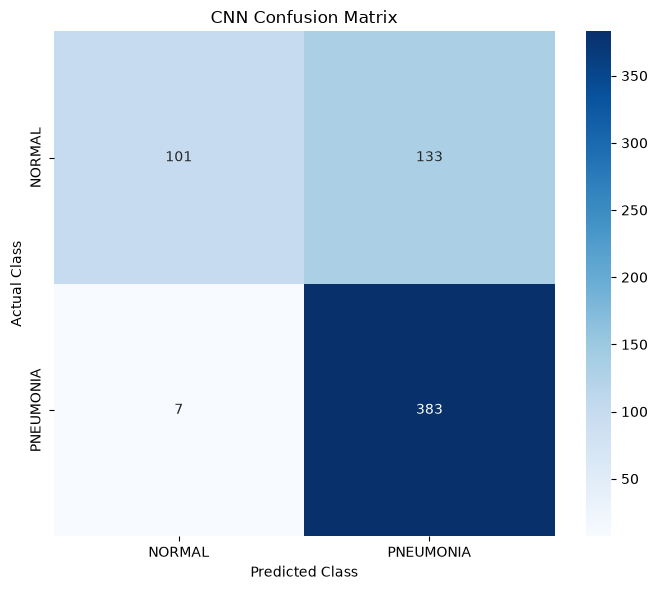

In [95]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [96]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nInterpretation:")
print(f"- {tn} NORMAL images were correctly classified as NORMAL.")
print(f"- {fp} NORMAL images were incorrectly classified as PNEUMONIA.")
print(f"- {fn} PNEUMONIA images were incorrectly classified as NORMAL.")
print(f"- {tp} PNEUMONIA images were correctly classified as PNEUMONIA.")

True Negatives : 101
False Positives: 133
False Negatives: 7
True Positives : 383

Interpretation:
- 101 NORMAL images were correctly classified as NORMAL.
- 133 NORMAL images were incorrectly classified as PNEUMONIA.
- 7 PNEUMONIA images were incorrectly classified as NORMAL.
- 383 PNEUMONIA images were correctly classified as PNEUMONIA.


In [97]:
test_generator.reset()

all_test_images = []
all_test_labels = []

for batch_images, batch_labels in test_generator:
    
    all_test_images.append(batch_images)
    all_test_labels.extend(
        batch_labels.astype(int)
    )
    
    if len(all_test_labels) >= test_generator.samples:
        break


all_test_images = np.concatenate(
    all_test_images
)[:test_generator.samples]

all_test_labels = np.array(
    all_test_labels
)[:test_generator.samples]


misclassified_indices = np.where(
    predictions != true_labels
)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices)
)

Number of misclassified images: 140


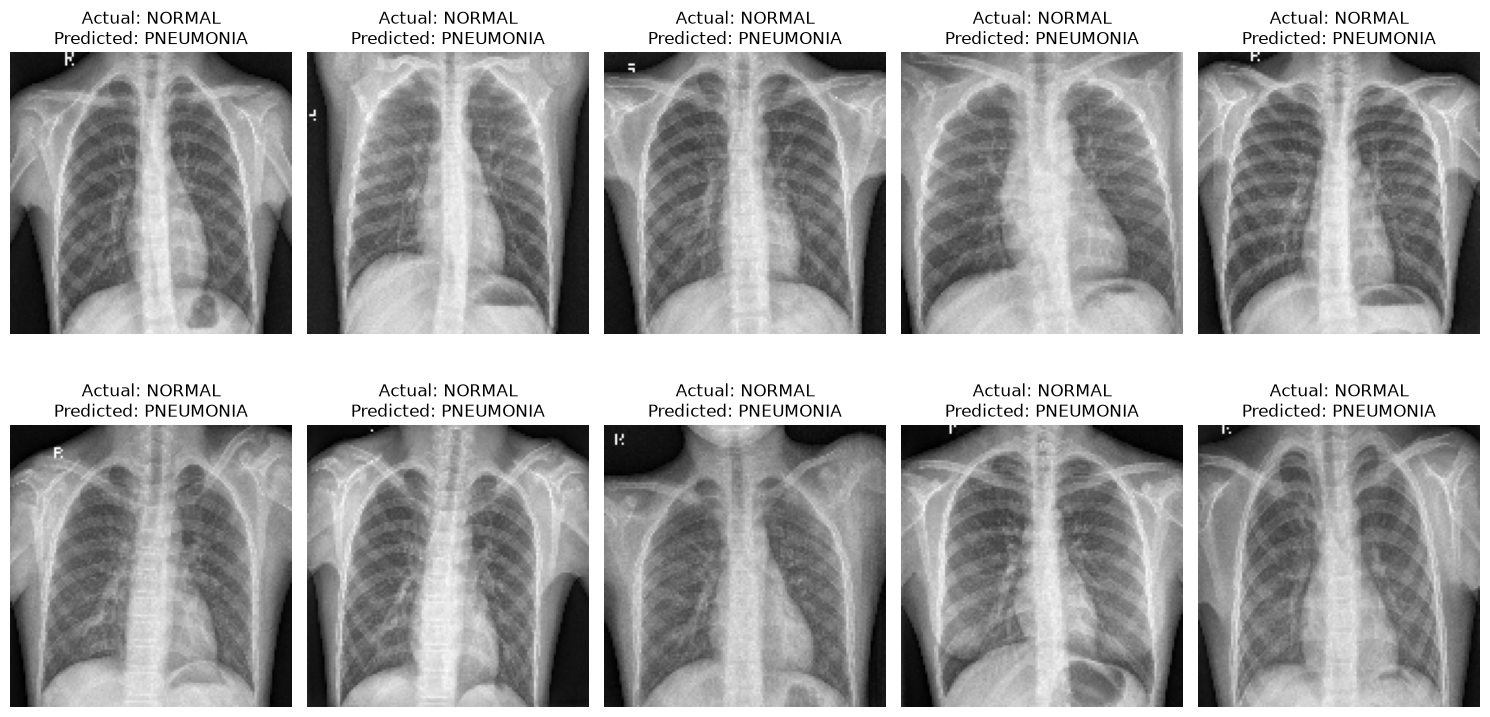

In [98]:
number_to_display = min(
    10,
    len(misclassified_indices)
)

plt.figure(figsize=(15, 8))

for i in range(number_to_display):
    
    index = misclassified_indices[i]
    
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(
        all_test_images[index].squeeze(),
        cmap="gray"
    )
    
    actual_class = CLASSES[
        true_labels[index]
    ]
    
    predicted_class = CLASSES[
        predictions[index]
    ]
    
    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}"
    )
    
    plt.axis("off")


plt.tight_layout()
plt.show()

In [99]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUROC"
    ],
    
    "CNN": [
        accuracy,
        precision,
        recall,
        f1,
        auroc
    ]
})

display(results)

,Metric,CNN
0,Accuracy,0.775641
1,Precision,0.742248
2,Recall,0.982051
3,F1-Score,0.845475
4,AUROC,0.927329


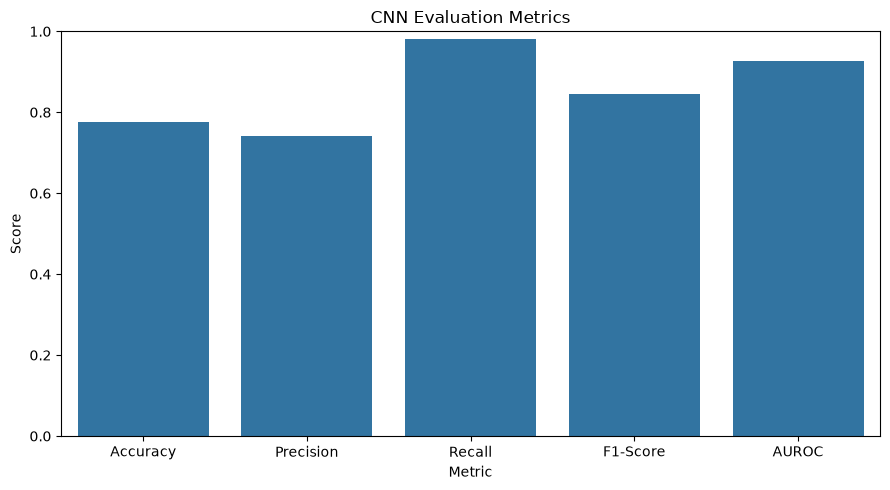

In [100]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Metric",
    y="CNN"
)

plt.ylim(0, 1)

plt.title(
    "CNN Evaluation Metrics"
)

plt.ylabel("Score")
plt.xlabel("Metric")

plt.tight_layout()
plt.show()

In [101]:
print("=" * 50)
print("FINAL CNN RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")

print("\n" + "=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

print(cm)

print("\n" + "=" * 50)
print("MISCLASSIFICATION SUMMARY")
print("=" * 50)

print("False Positives:", fp)
print("False Negatives:", fn)

FINAL CNN RESULTS
Accuracy : 0.7756
Precision: 0.7422
Recall   : 0.9821
F1-Score : 0.8455
AUROC    : 0.9273

CONFUSION MATRIX
[[101 133]
 [  7 383]]

MISCLASSIFICATION SUMMARY
False Positives: 133
False Negatives: 7
